# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## NB_P3_19: Optuna trials evaluation (PhysNet + RhythmMamba)

### What this notebook does
Documents the two Phase-3 hyperparameter searches from their saved SQLite studies -
trial counts, best configurations, optimization history, hyperparameter importances,
and the per-dataset behaviour logged per trial - to draw a documented conclusion about
what tuning did and did not achieve and to inform future experiments. 

## Imports and Setup

In [1]:
import optuna
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# point these at the two study DBs (this notebook's folder, or set full paths)
DBS = {
    "PhysNet" : r"D:\code\QualityPhys - CRVSE Project\Data\Phase3\physnet_optuna_NB_P3_13.db", 
    "RhythmMamba": r"D:\code\QualityPhys - CRVSE Project\Data\Phase3\rhythmmamba_optuna_NB_P3_14.db"}

studies = {}
for arch, db in DBS.items():
    assert Path(db).exists(), f'missing {db} - set the path'
    storage = f'sqlite:///{db}'
    for sn in optuna.study.get_all_study_names(storage):
        st = optuna.load_study(study_name=sn, storage=storage)
        studies[arch] = st
        states = pd.Series([t.state.name for t in st.trials]).value_counts().to_dict()
        done = [t for t in st.trials if t.state.name == 'COMPLETE']
        print('=' * 72)
        print(f'{arch} | db "{db}" | study "{sn}"')
        print(f'trials: {len(st.trials)}  {states}')
        if done:
            print(f'best value (proxy val MAE): {st.best_value:.3f}  @ trial {st.best_trial.number}')
            print(f'searched params : {sorted(st.best_trial.params.keys())}')
            print(f'best params     : {st.best_params}')
            print(f'best user_attrs : {dict(st.best_trial.user_attrs)}')
        else:
            print('no COMPLETE trials')

PhysNet | db "D:\code\QualityPhys - CRVSE Project\Data\Phase3\physnet_optuna_NB_P3_13.db" | study "physnet_v1_mcd_ubfc_dlcn"
trials: 57  {'PRUNED': 52, 'COMPLETE': 5}
best value (proxy val MAE): 8.056  @ trial 6
searched params : ['aug_prob', 'batch_size', 'dropout', 'lambda_freq', 'lr', 'weight_decay']
best params     : {'lr': 0.0011736424885649085, 'weight_decay': 1.2385137298860926e-05, 'lambda_freq': 0.32339518335564726, 'dropout': 0.08526206184364576, 'aug_prob': 0.3260206371941118, 'batch_size': 16}
best user_attrs : {'best_epoch': 9, 'bias': 0.98, 'n': 425, 'per_dataset': {'DLCN': 4.891, 'MCD': 10.688, 'UBFC-rPPG': 4.192}, 'r': 0.502, 'rmse': 16.481}
RhythmMamba | db "D:\code\QualityPhys - CRVSE Project\Data\Phase3\rhythmmamba_optuna_NB_P3_14.db" | study "rhythmmamba_v1_mcd_ubfc_dlcn"
trials: 37  {'PRUNED': 19, 'COMPLETE': 18}
best value (proxy val MAE): 8.367  @ trial 32
searched params : ['aug_prob', 'batch_size', 'lambda_freq', 'lr', 'weight_decay']
best params     : {'lr': 0

## Per-trial table and per-dataset spread
Flattens each study into one row per trial (objective value, per-dataset MAE, and the
sampled hyperparameters) and measures how far each dataset's error ranged across the
completed trials - a tight MCD range means no hyperparameter setting reached it.

In [2]:
def trials_df(st):
    rows = []
    for t in st.trials:
        ua = t.user_attrs or {}
        per = ua.get('per_dataset') or {}
        row = dict(trial=t.number, state=t.state.name, value=t.value,
                   mcd=per.get('MCD'), dlcn=per.get('DLCN'), ubfc=per.get('UBFC-rPPG'),
                   bias=ua.get('bias'), r=ua.get('r'), best_epoch=ua.get('best_epoch'))
        row.update(t.params)
        rows.append(row)
    return pd.DataFrame(rows)

TRIALS = {arch: trials_df(st) for arch, st in studies.items()}

for arch, df in TRIALS.items():
    comp = df[df.state == 'COMPLETE'].sort_values('value')
    print('=' * 72, arch)
    print(f'trials {len(df)} | complete {len(comp)} | pruned {int((df.state == "PRUNED").sum())}')
    cols = [c for c in ['trial', 'value', 'mcd', 'dlcn', 'ubfc', 'bias', 'r', 'best_epoch',
                        'lr', 'weight_decay', 'lambda_freq', 'dropout', 'aug_prob', 'batch_size'] if c in comp.columns]
    print('\ntop completed trials (value = proxy val MAE):')
    print(comp[cols].head(6).round(4).to_string(index=False))
    print('\nper-dataset MAE spread across COMPLETED trials (how much tuning moved each):')
    for d in ['mcd', 'dlcn', 'ubfc']:
        s = comp[d].dropna()
        if len(s):
            print(f'  {d:4s}: min {s.min():.2f} | median {s.median():.2f} | max {s.max():.2f} | range {s.max()-s.min():.2f} | std {s.std():.2f}  (n {len(s)})')

======================================================================== PhysNet
trials 57 | complete 5 | pruned 52

top completed trials (value = proxy val MAE):
 trial  value    mcd  dlcn  ubfc  bias     r  best_epoch     lr  weight_decay  lambda_freq  dropout  aug_prob  batch_size
     6 8.0564 10.688 4.891 4.192 0.980 0.502           9 0.0012        0.0000       0.3234   0.0853    0.3260          16
    55 8.0956 11.243 4.280 4.192 0.267 0.503           8 0.0004        0.0002       0.2828   0.2034    0.3435           8
     0 8.2137 10.637 5.380 2.796 1.898 0.502           9 0.0010        0.0001       0.2000   0.0000    0.5000           8
    28 8.5646 12.050 4.402 2.796 1.724 0.456           9 0.0029        0.0006       0.2415   0.0402    0.6230           8
     3 9.0502 12.453 5.014 2.796 2.127 0.489           9 0.0022        0.0002       0.3686   0.0103    0.6880           8

per-dataset MAE spread across COMPLETED trials (how much tuning moved each):
  mcd : min 10.64 | median 

PhysNet      importance aug_prob      0.445
PhysNet      importance lr            0.228
PhysNet      importance lambda_freq   0.183
PhysNet      importance weight_decay  0.095
PhysNet      importance dropout       0.048
PhysNet      importance batch_size    0.000
RhythmMamba  importance lr            0.549
RhythmMamba  importance lambda_freq   0.293
RhythmMamba  importance weight_decay  0.088
RhythmMamba  importance aug_prob      0.049
RhythmMamba  importance batch_size    0.021


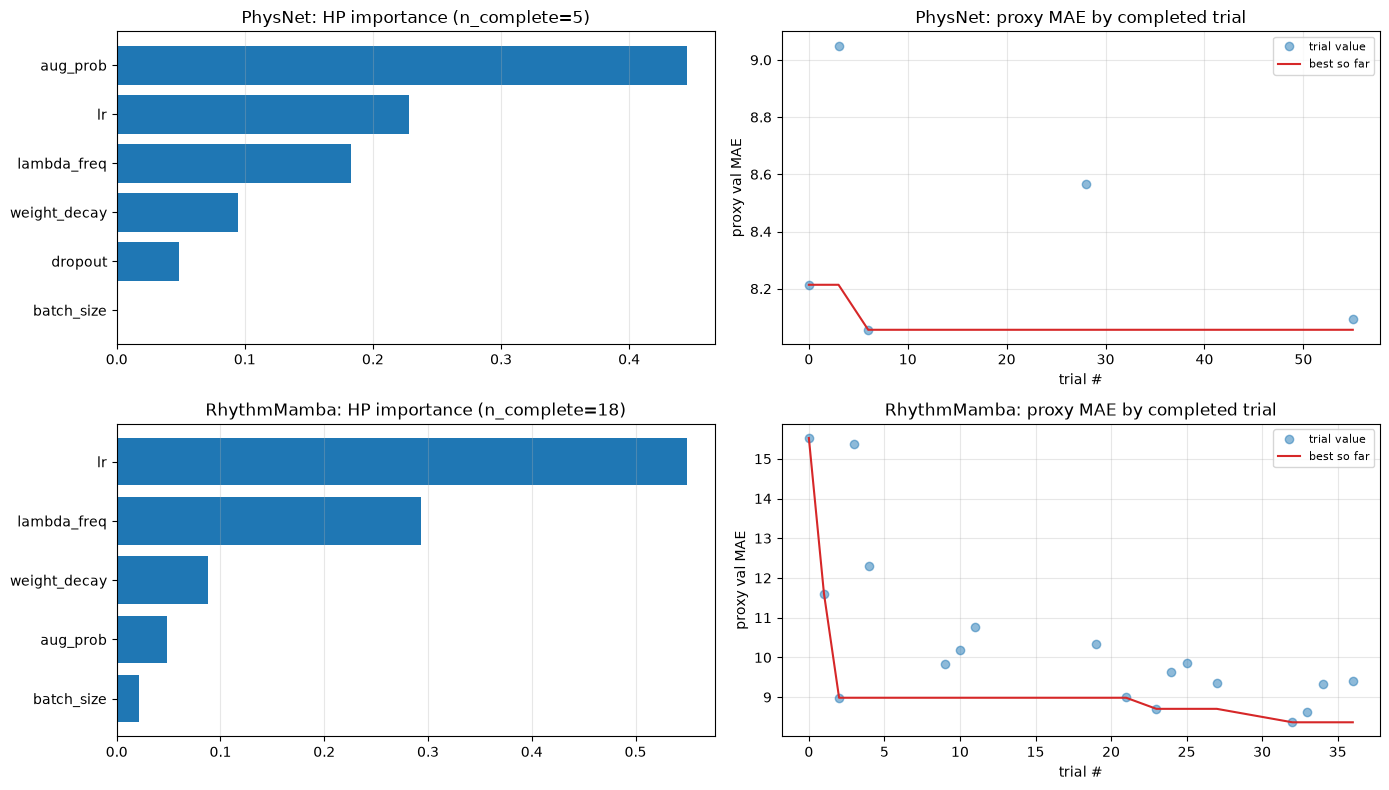

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for j, (arch, st) in enumerate(studies.items()):
    n_comp = sum(t.state.name == 'COMPLETE' for t in st.trials)
    try:
        imp = optuna.importance.get_param_importances(st)
    except Exception as e:
        imp = {}; print(arch, 'importance error:', e)
    ax = axes[j, 0]
    if imp:
        ks = list(imp.keys())[::-1]
        ax.barh(ks, [imp[k] for k in ks], color='tab:blue')
        for k, v in imp.items():
            print(f'{arch:12s} importance {k:13s} {v:.3f}')
    ax.set(title=f'{arch}: HP importance (n_complete={n_comp})'); ax.grid(alpha=0.3, axis='x')

    comp = sorted([t for t in st.trials if t.state.name == 'COMPLETE' and t.value is not None], key=lambda t: t.number)
    ax2 = axes[j, 1]
    if comp:
        nums = [t.number for t in comp]; vals = [t.value for t in comp]
        ax2.plot(nums, vals, 'o', alpha=0.5, label='trial value')
        ax2.plot(nums, np.minimum.accumulate(vals), '-', color='tab:red', label='best so far')
        ax2.legend(fontsize=8)
    ax2.set(title=f'{arch}: proxy MAE by completed trial', xlabel='trial #', ylabel='proxy val MAE'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Conclusions

Two Phase-3 hyperparameter searches are documented here: PhysNet (57 trials, 5 completed
under a Hyperband pruner) and RhythmMamba (37 trials, 18 completed under a median pruner),
each minimizing a short-proxy cross-subject validation MAE over a literature-anchored space
(learning rate, weight decay, frequency-loss weight, augmentation probability, batch size,
and - for PhysNet - dropout).

**The searches are a well-run negative: tuning did not beat the fixed-hyperparameter
baselines.** PhysNet's best proxy value (8.06) retrained to 7.24, indistinguishable from
the untuned screen (7.31); RhythmMamba's best proxy (8.37) is worse than its untuned
30-epoch screen (6.83). No configuration improved on the baselines.

**The bottleneck was hyperparameter-invariant.** Across every completed PhysNet
configuration, MCD - the noisy pulse-ox reference that caps this corpus - ranged only
10.64 to 12.45, and the best value any setting reached (10.64) equals the untuned baseline
(10.69). The optimization history flattens by trial 6 and never improves over the following
fifty. The search space simply contains no setting that moves MCD, while the clean sets
(DLCN, UBFC-rPPG) were already near their floor. The error ceiling was therefore a property
of the data and the training objective, not of the hyperparameters.

**Which knobs the search registered.** PhysNet was most sensitive to augmentation
probability (0.45) and learning rate (0.23); RhythmMamba to learning rate (0.55) and the
frequency-loss weight (0.29). These moved only small overall-MAE variation, never the MCD
floor.

**A methodological note on RhythmMamba.** It converges late (validation clicks around epoch
13-21), but the proxy stopped at 16 epochs, so more than half its completed trials were
still under-converged when scored (UBFC-rPPG frozen at its constant-prediction value in the
majority of trials). The search was under-powered for this architecture: a late-clicking
model needs a longer proxy or a click-aware pruner, or the objective reflects convergence
speed rather than final quality.

**Resolution and forward guidance.** The productive lever was the training objective, not
the hyperparameters. Replacing the frequency-match term with an SNR frequency loss
(NB_P3_18) cut MCD from 10.69 to 6.84 on the same data - achieving in one loss change what
the whole search could not. The guidance follows directly: do not tune to escape a
reference-noise or data ceiling; change the loss or data first, settle the recipe, and only
then run a longer-proxy hyperparameter search.